In [23]:
from sklearn.datasets import load_wine
import numpy as np
import pandas as pd
X, y = load_wine(return_X_y=True)
print(X.shape,y.shape)

X_df = pd.DataFrame(X)
y_df = pd.DataFrame(y)

(178, 13) (178,)


# bayes

In [24]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
model_nb = GaussianNB()
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=101, test_size=0.2)
model_nb.fit(X_train,y_train)
y_nb_pred = model_nb.predict(X_test)

In [25]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_nb_pred))

              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       0.93      1.00      0.96        13
           2       1.00      1.00      1.00         9

    accuracy                           0.97        36
   macro avg       0.98      0.98      0.98        36
weighted avg       0.97      0.97      0.97        36



# LDA + Logistic

In [26]:
# LDA
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components = 2)
lda.fit(X,y)
X_lda = lda.transform(X)


In [27]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_lda, y, random_state=101, test_size=0.2)

In [28]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [29]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00         9

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



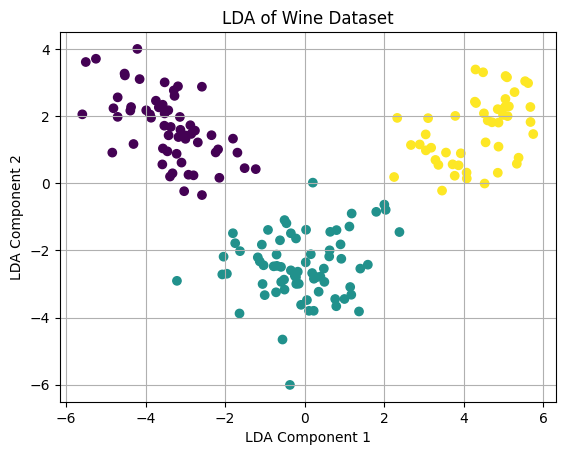

In [30]:
import matplotlib.pyplot as plt

# Create a scatter plot of the LDA-transformed data
plt.figure()
scatter = plt.scatter(X_lda[:, 0], X_lda[:, 1], c=y)

plt.title('LDA of Wine Dataset')
plt.xlabel('LDA Component 1')
plt.ylabel('LDA Component 2')
plt.grid(True)
plt.show()

# pca+logistic

In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(0.95)
pca.fit(X_scaled)
X_pca = pca.transform(X_scaled)
X_pca_train, X_pca_test, y_pca_train, y_pca_test = train_test_split(X_pca,y, random_state=101, test_size=0.2)

In [32]:
count = 0
for i,j in zip(y_pca_test, y_test):
  if i == j:
    count +=1
print(count)

36


In [33]:
model2 = LogisticRegression()
model2.fit(X_pca_train, y_pca_train)
y2_pred = model2.predict(X_pca_test)

print(classification_report(y_pca_test, y2_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00         9

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [34]:
print(y_test)

[0 0 2 0 2 1 2 0 1 1 0 1 0 0 0 0 1 2 1 1 1 2 2 2 0 0 1 1 2 1 2 1 1 0 0 0]


In [35]:
y2_proba = model2.predict_proba(X_pca_test)
for label, proba in zip(y_test, y2_proba):
  print(f"Class = {label} {proba}")


Class = 0 [0.94172842 0.05039529 0.00787629]
Class = 0 [0.90426787 0.09472816 0.00100398]
Class = 2 [0.00103527 0.00120142 0.9977633 ]
Class = 0 [9.99724720e-01 1.78433651e-04 9.68462474e-05]
Class = 2 [1.01752213e-03 4.99761595e-04 9.98482716e-01]
Class = 1 [0.002446   0.97460742 0.02294658]
Class = 2 [0.00454444 0.00239382 0.99306174]
Class = 0 [9.98594972e-01 1.05825761e-03 3.46770068e-04]
Class = 1 [5.89375237e-02 9.40755360e-01 3.07116728e-04]
Class = 1 [8.70038902e-02 9.12639114e-01 3.56995502e-04]
Class = 0 [9.99215758e-01 4.22347463e-04 3.61894141e-04]
Class = 1 [0.10126505 0.89476167 0.00397328]
Class = 0 [0.75644909 0.20093401 0.04261691]
Class = 0 [0.93605797 0.05025569 0.01368633]
Class = 0 [9.98751281e-01 7.54376703e-04 4.94342030e-04]
Class = 0 [9.99402276e-01 2.17731618e-04 3.79992866e-04]
Class = 1 [2.04729930e-03 9.97315296e-01 6.37404254e-04]
Class = 2 [0.00649211 0.08311695 0.91039094]
Class = 1 [8.84016675e-04 9.98914783e-01 2.01200008e-04]
Class = 1 [1.03885082e-03

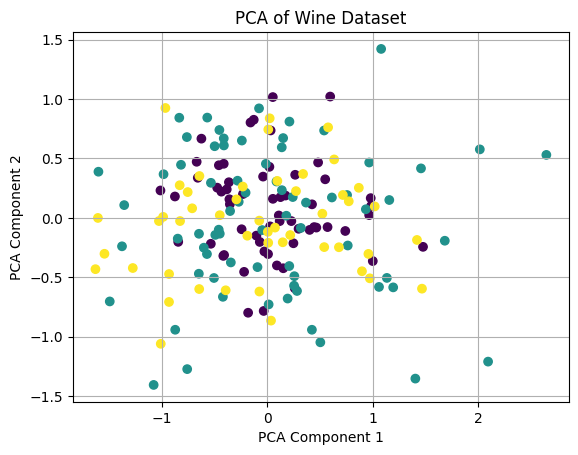

In [51]:
import matplotlib.pyplot as plt

# Create a scatter plot of the LDA-transformed data
plt.figure()
scatter = plt.scatter(X_pca[:,6], X_pca[:,9], c=y)

plt.title('PCA of Wine Dataset')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True)
plt.show()

# Try using Pipeline

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.naive_bayes import GaussianNB

preprocess = PCA(n_components=0.99)
#preprocess = LinearDiscriminantAnalysis(n_components=2)

model = LogisticRegression()
model = GaussianNB()
# Define the steps of the pipeline
steps = [("scaler", StandardScaler()),
         ("preprocessing", preprocess),
         ("model", model)]

pipeline = Pipeline(steps)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=101, test_size=0.2)
pipeline.fit(X_train, y_train)

y_pred_pipeline = pipeline.predict(X_test)
print(classification_report(y_test, y_pred_pipeline))

              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       0.93      1.00      0.96        13
           2       1.00      1.00      1.00         9

    accuracy                           0.97        36
   macro avg       0.98      0.98      0.98        36
weighted avg       0.97      0.97      0.97        36



In [38]:
pipeline["model"].classes_

array([0, 1, 2])

# Cross val

In [39]:
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score

sss1 = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)
kf = KFold(n_splits=5)


In [40]:
from sklearn.model_selection import cross_val_score

# Use cross_val_score with the pipeline and sss1 as the cross-validation strategy
scores = cross_val_score(pipeline, X, y, cv=sss1, scoring='accuracy')
print("Cross-validation accuracy scores:", scores)
print("Mean cross-validation accuracy:", scores.mean())

Cross-validation accuracy scores: [1.         1.         0.94444444 1.         0.94444444]
Mean cross-validation accuracy: 0.9777777777777779


In [41]:
scores = cross_val_score(pipeline, X, y, cv=kf, scoring='accuracy')
print("Cross-validation accuracy scores:", scores)
print("Mean cross-validation accuracy:", scores.mean())

Cross-validation accuracy scores: [0.94444444 0.94444444 0.97222222 0.94285714 0.82857143]
Mean cross-validation accuracy: 0.9265079365079364


# Grid Search

In [42]:
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler


# Define the pipeline with a placeholder for PCA
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("classify", LogisticRegression())
])

# Define the parameters grid for the grid search, prefixing with the step name 'pca'
parameters = {'pca__n_components': [0.7, 0.8, 0.9, 0.95, 0.99]}

# Correctly instantiate GridSearchCV with the pipeline as the estimator
grid_search = GridSearchCV(estimator=pipeline, param_grid=parameters,scoring = "accuracy", cv=5)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=101, test_size=0.2)

# Fit the grid search on the training data
grid_search.fit(X_train, y_train)

# Predict using the best estimator found by grid search
y_pred = grid_search.predict(X_test)

print("Best parameters found:", grid_search.best_params_)
print(classification_report(y_test, y_pred))

Best parameters found: {'pca__n_components': 0.95}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00         9

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

